In [1]:
from langchain.schema import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv, find_dotenv
import os

# -----------------------------
# ✅ Step 1: Load Environment Variables
# -----------------------------
load_dotenv(find_dotenv())  # Automatically locates nearest .env file

# Ensure Hugging Face token is available
hf_token = os.getenv("HF_TOKEN")
if not hf_token:
    raise ValueError("HF_TOKEN is missing from your .env file.")

# Set environment for HuggingFace
os.environ['HF_TOKEN'] = hf_token

# -----------------------------
# ✅ Step 2: Initialize Embedding Model
# -----------------------------
embedding_function = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},  # use "cuda" if GPU is available
)

# -----------------------------
# ✅ Step 3: Sample Gym Documents
# -----------------------------
docs = [
    Document(
        page_content=(
            "Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. "
            "With over 15 years of experience in professional athletics, Marcus established the gym "
            "to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet "
            "and features state-of-the-art equipment."
        ),
        metadata={"source": "about.txt"}
    ),
    Document(
        page_content=(
            "Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. "
            "On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. "
            "Members with Premium access can enter using their key cards 24/7, including holidays."
        ),
        metadata={"source": "hours.txt"}
    ),
    Document(
        page_content=(
            "Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; "
            "Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, "
            "personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. "
            "Corporate partnerships are available for companies with 10+ employees joining."
        ),
        metadata={"source": "membership.txt"}
    ),
    Document(
        page_content=(
            "Group fitness classes at Peak Performance Gym include Yoga (beginner, intermediate, advanced), HIIT, Zumba, "
            "Spin Cycling, CrossFit, and Pilates. Beginner classes are held every Monday and Wednesday at 6:00 PM. "
            "Intermediate and advanced classes are scheduled throughout the week. The full schedule is available on our mobile app or at the reception desk."
        ),
        metadata={"source": "classes.txt"}
    ),
    Document(
        page_content=(
            "Personal trainers at Peak Performance Gym are all certified professionals with minimum 5 years of experience. "
            "Each new member receives a complimentary fitness assessment and one free session with a trainer. "
            "Our head trainer, Neha Kapoor, specializes in rehabilitation fitness and sports-specific training. "
            "Personal training sessions can be booked individually (₹800/session) or in packages of 10 (₹7,000) or 20 (₹13,000)."
        ),
        metadata={"source": "trainers.txt"}
    ),
    Document(
        page_content=(
            "Peak Performance Gym's facilities include a cardio zone with 30+ machines, strength training area, functional fitness space, "
            "dedicated yoga studio, spin class room, swimming pool (25m), sauna and steam rooms, juice bar, and locker rooms with shower facilities. "
            "Our equipment is replaced or upgraded every 3 years to ensure members have access to the latest fitness technology."
        ),
        metadata={"source": "facilities.txt"}
    )
]

# -----------------------------
# ✅ Step 4: Create Chroma Vector Store
# -----------------------------
db = Chroma.from_documents(docs, embedding_function)
print("✅ Vector store created with", len(docs), "documents.")


c:\Users\User\Desktop\Langgraph_crash_course\langgraph-main\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Vector store created with 6 documents.


In [2]:
# ✅ Create retriever from vector store
retriever = db.as_retriever(search_type="mmr", search_kwargs = {"k": 3})


In [3]:
from langchain.tools.retriever import create_retriever_tool
from langchain_core.tools import tool

# ✅ Create tool using retriever
retriever_tool = create_retriever_tool(
    retriever,
    name="retriever_tool",
    description=(
        "Useful for answering questions related to: "
        "Gym History & Founder, Operating Hours, Membership Plans, Fitness Classes, "
        "Personal Trainers, and Facilities & Equipment of Peak Performance Gym."
    ),
)

# ✅ Fallback tool for irrelevant questions
@tool
def off_topic():
    """Catch all questions NOT related to Peak Performance Gym's services or information"""
    return "Forbidden – this question is outside the scope of Peak Performance Gym."

# ✅ Combine tools into a list
tools = [retriever_tool, off_topic]

print("✅ Tools registered:", [tool.name for tool in tools])


✅ Tools registered: ['retriever_tool', 'off_topic']


In [5]:
from typing import Annotated, Sequence, Literal, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


# ✅ State schema for graph traversal
class AgentState(TypedDict):
    # Holds the message history; LangGraph will automatically accumulate these
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [25]:
from langchain_core.messages import HumanMessage
from langgraph.graph import END, StateGraph, START
from langchain_groq import ChatGroq
from dotenv import load_dotenv, find_dotenv
import os
from typing import Literal

# -----------------------------
# ✅ Load environment variables
# -----------------------------
load_dotenv(find_dotenv())
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("Missing GROQ_API_KEY in environment")

# -----------------------------
# ✅ Initialize model
# -----------------------------
# Re-bind tools each time (optional: you can bind once outside)
model = ChatGroq(model="llama-3.1-8b-instant", groq_api_key=groq_api_key)
model = model.bind_tools(tools)

# -----------------------------
# ✅ Agent node
# -----------------------------
def agent(state):
    messages = state["messages"]
    response = model.invoke(messages)
    
    # Return only the new message; LangGraph will auto-append via add_messages
    return {"messages": [response]}

# -----------------------------
# ✅ Routing node to continue or end
# -----------------------------
def should_continue(state) -> Literal["tools", END]:
    messages = state["messages"]
    
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return "tools"
    return END


In [26]:
from langchain_core.messages import AIMessage

def tool_node(state):
    messages = state["messages"]
    last_message = messages[-1]
    tool_calls = last_message.tool_calls

    results = []

    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        args = tool_call.get("args", {})

        if tool_name == "retriever_tool":
            result = tools[0].invoke(args)  # tools[0] = retriever_tool
        elif tool_name == "off_topic":
            result = tools[1].invoke({})    # tools[1] = off_topic
        else:
            result = f"Tool '{tool_name}' not recognized."

        # 🔥 Return response as clean AI message (no tool_calls → prevents loop)
        results.append(AIMessage(content=result))

    return {"messages": results}


In [27]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# ✅ Initialize the workflow graph
workflow = StateGraph(AgentState)

# Add core nodes
workflow.add_node("agent", agent)
# tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)

# Add edges
workflow.add_edge(START, "agent")

# After agent responds, increment the iteration, then route conditionally
workflow.add_conditional_edges("agent", should_continue)

# Loop tools → agent
workflow.add_edge("tools", "agent")

# Compile the graph
graph = workflow.compile()

print("✅ Graph compiled successfully.")


✅ Graph compiled successfully.


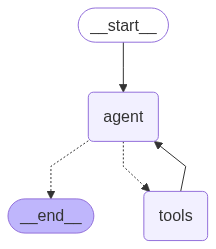

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [28]:
graph.invoke(
    input={"messages": [HumanMessage(content="Who is the owner of apple?")]}
)

{'messages': [HumanMessage(content='Who is the owner of apple?', additional_kwargs={}, response_metadata={}, id='a8519d34-6f5f-4921-8abf-2e6349133761'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'x5tgxspyw', 'function': {'arguments': '{}', 'name': 'off_topic'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 351, 'total_tokens': 361, 'completion_time': 0.021714423, 'prompt_time': 0.020817084, 'queue_time': 0.050437036000000005, 'total_time': 0.042531507}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8ab2e50475', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--eb17e588-b119-4547-a00e-423bb6d520fd-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 'x5tgxspyw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 351, 'output_tokens': 10, 'total_tokens': 361}),
  AIMessage(content='Forbidden – this question is outside the scope of Peak Performance Gym.', additional_kwargs={}, re

In [29]:
graph.invoke(input={
    "messages": [HumanMessage(content="Who is the owner of Peak Performance Gym's and what are the timings?")]
})

{'messages': [HumanMessage(content="Who is the owner of Peak Performance Gym's and what are the timings?", additional_kwargs={}, response_metadata={}, id='8d5ba70f-3e6f-4229-a408-34213422f457'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nrvkx6ke0', 'function': {'arguments': '{"query":"Peak Performance Gym\'s owner and operating hours"}', 'name': 'retriever_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 359, 'total_tokens': 382, 'completion_time': 0.0329983, 'prompt_time': 0.021510987, 'queue_time': 0.050060538, 'total_time': 0.054509287}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8ab2e50475', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--87131f03-e42f-412a-baf7-4e57c8eb1cfb-0', tool_calls=[{'name': 'retriever_tool', 'args': {'query': "Peak Performance Gym's owner and operating hours"}, 'id': 'nrvkx6ke0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 359, 'out